In [1]:
#Adding current repo to path because it wasn't there
import sys
import os
print(sys.path)
sys.path.append(os.path.abspath('/home/av_linux/AIRXD-CNN'))

['/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python311.zip', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/lib-dynload', '', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/site-packages', '/home/av_linux/AIRXD-ML-PUB']


In [2]:
import numpy as np
from pyFAI import load
from pyFAI.geometryRefinement import GeometryRefinement
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from pyFAI.detectors import Detector
from pyFAI.io.ponifile import PoniFile
from pyFAI.detectors.orientation import Orientation
from enum import Enum

In [3]:
import numpy as np
import imageio as iio
import os
from glob import glob
from airxd_cnn.poni_parse import convert_to_imctrl
import airxd_old
from airxd.mask import MASK
from airxd_cnn.transforms import powder_normalize
import importlib
import pyFAI
from scipy import ndimage
from scipy.ndimage import label
from skimage.measure import regionprops
from airxd_cnn.poni_parse import parse_poni_file, create_2theta_map_poni

In [4]:
import matplotlib.pyplot as plt

# Core Calibration Model

In [5]:
class DetectorModes(Enum):
    CUSTOM = 1
    NEXUS = 2
    PREDEFINED = 3

In [ ]:
class SimplifiedCalibrationModel:
    def __init__(self):
        self.detector = Detector(pixel1=79e-6, pixel2=79e-6)  # default detector
        self.pattern_geometry = None
        self.cake_geometry = None
        self.polarization_factor = 0.99
        self.correct_solid_angle = True
        self.pattern_geometry_img_shape = None
        self.orig_pixel1 = 79e-6
        self.orig_pixel2 = 79e-6
        
    def poni_flipud(self, poni_dict):
        """
        Flips the detector up-down orientation in a poni configuration dictionary.
        This is crucial for correct geometry!
        """
        if "detector_config" not in poni_dict:
            return poni_dict
            
        if "orientation" not in poni_dict["detector_config"]:
            return poni_dict
            
        orientation = poni_dict["detector_config"]["orientation"]

        print("Orientation is:", orientation)
        
        # Apply the orientation transformations as in the original code
        if orientation in (Orientation.Unspecified, Orientation.BottomRight):
            print("Flipped 1")
            poni_dict["detector_config"]["orientation"] = Orientation.TopRight
        elif orientation == Orientation.TopRight:
            print("Flipped 2")
            poni_dict["detector_config"]["orientation"] = Orientation.BottomRight
        elif orientation == Orientation.BottomLeft:
            print("Flipped 3")
            poni_dict["detector_config"]["orientation"] = Orientation.TopLeft
        elif orientation == Orientation.TopLeft:
            print("Flipped 4")
            poni_dict["detector_config"]["orientation"] = Orientation.BottomLeft
            
        return poni_dict
    
    def load_poni(self, poni_filename):
        """
        Load calibration from .poni file with proper orientation handling
        """
        # Read the poni file
        poni_dict = PoniFile(poni_filename).as_dict()
        # Critical: Apply orientation correction if needed
        if (poni_dict.get("poni_version", 1) >= 2 and 
            "detector_config" in poni_dict and
            "orientation" in poni_dict["detector_config"]):
            poni_dict = self.poni_flipud(poni_dict)

        print("Poni_dict after", poni_dict['detector_config']['orientation'])
        
        # Initialize geometry with default parameters
        self.pattern_geometry = GeometryRefinement(
            wavelength=0.3344e-10,  # default wavelength
            detector=self.detector,
            poni1=0,
            poni2=0
        )
        
        # Set the configuration from the corrected poni dictionary
        self.pattern_geometry.set_config(poni_dict)

        print(self.pattern_geometry.get_config())
        
        # Update pixel sizes from the loaded configuration
        self.orig_pixel1 = self.pattern_geometry.pixel1
        self.orig_pixel2 = self.pattern_geometry.pixel2
        
        # Update detector if it's been specified in the poni file
        if (self.pattern_geometry.pixel1 == self.detector.pixel1 and 
            self.pattern_geometry.pixel2 == self.detector.pixel2):
            self.pattern_geometry.detector = self.detector
        else:
            # Reset detector with new pixel sizes
            self.detector = Detector(
                pixel1=self.pattern_geometry.pixel1,
                pixel2=self.pattern_geometry.pixel2
            )
            self.pattern_geometry.detector = self.detector
        
        # Create cake geometry for 2D integration if needed
        self.create_cake_geometry()
        
    def create_cake_geometry(self):
        """Create azimuthal integrator for 2D integration"""
        self.cake_geometry = AzimuthalIntegrator()
        self.cake_geometry.set_config(self.pattern_geometry.get_config())
        self.cake_geometry.detector = self.detector
        
    def integrate_1d(self, img_data, num_points=None, mask=None,
                     unit="2th_deg", method="csr", azimuth_range=None,
                     filename=None):
        """
        Perform 1D integration with proper setup
        """
        # Check if image shape has changed
        if self.pattern_geometry_img_shape != img_data.shape:
            self.pattern_geometry.reset()
            self.pattern_geometry_img_shape = img_data.shape
            
        # Update detector shape
        self.detector.shape = img_data.shape
        self.detector.max_shape = img_data.shape
        
        # Prepare mask
        final_mask = self._prepare_mask(mask)
        
        # Check for completely masked image
        if final_mask is not None:
            if np.sum(final_mask) == img_data.shape[0] * img_data.shape[1]:
                return np.array([]), np.array([])
        
        # Calculate number of points if not specified
        if num_points is None:
            num_points = self._calculate_num_points(img_data.shape)
        
        # Perform integration
        if unit == "d_A":
            # Special handling for d-spacing
            tth, intensity = self.pattern_geometry.integrate1d(
                img_data,
                num_points,
                method=method,
                unit="2th_deg",
                azimuth_range=azimuth_range,
                mask=final_mask,
                polarization_factor=self.polarization_factor,
                correctSolidAngle=self.correct_solid_angle,
                filename=filename
            )
            # Convert to d-spacing
            wavelength_angstrom = self.pattern_geometry.wavelength * 1e10
            tth = wavelength_angstrom / (2 * np.sin(np.radians(tth) / 2))
        else:
            tth, intensity = self.pattern_geometry.integrate1d(
                img_data,
                num_points,
                method=method,
                unit=unit,
                azimuth_range=azimuth_range,
                mask=final_mask,
                polarization_factor=self.polarization_factor,
                correctSolidAngle=self.correct_solid_angle,
                filename=filename
            )
            
        return tth, intensity
    
    def integrate_2d(
        self,
        img_data,
        mask=None,
        polarization_factor=None,
        unit="2th_deg",
        method="csr",
        rad_points=500,
        azimuth_points=360,
        azimuth_range=None,
    ):
        if polarization_factor is None:
            polarization_factor = self.polarization_factor

        if self.cake_geometry_img_shape != img_data.shape:
            # if cake geometry was used on differently shaped image before the azimuthal integrator needs to be reset
            self.cake_geometry.reset()
            self.cake_geometry_img_shape = img_data.shape

        self.num_points = rad_points

        res = self.cake_geometry.integrate2d(
            img_data,
            rad_points,
            azimuth_points,
            azimuth_range=azimuth_range,
            method=method,
            mask=mask,
            unit=unit,
            polarization_factor=polarization_factor,
            correctSolidAngle=self.correct_solid_angle,
        )

        self.cake_img = res[0]
        self.cake_tth = res[1]
        self.cake_azi = res[2]
        return self.cake_img
    
    def _calculate_num_points(self, img_shape):
        """Calculate number of points based on image geometry"""
        # Following the original implementation
        fit2d_params = self.pattern_geometry.getFit2D()
        center_x = fit2d_params["centerX"]
        center_y = fit2d_params["centerY"]
        width, height = img_shape
        
        if 0 < center_x < width:
            side1 = max(abs(width - center_x), center_x)
        else:
            side1 = width
            
        if 0 < center_y < height:
            side2 = max(abs(height - center_y), center_y)
        else:
            side2 = height
            
        max_dist = np.sqrt(side1**2 + side2**2)
        return int(max_dist * 1.5)  # 1.5 is the max_dist_factor
    
    def _prepare_mask(self, user_mask):
        """Prepare integration mask combining user and detector masks"""
        detector_mask = None
        
        # Check for detector mask
        if hasattr(self.detector, 'mask') and self.detector.mask is not None:
            detector_mask = self.detector.mask
        elif hasattr(self.detector, 'calc_mask'):
            self.detector.calc_mask()
            if hasattr(self.detector, 'mask'):
                detector_mask = self.detector.mask
                
        # Combine masks
        if user_mask is None:
            return detector_mask
        elif detector_mask is None:
            return user_mask
        else:
            if user_mask.shape == detector_mask.shape:
                return np.logical_or(user_mask, detector_mask)
            else:
                return user_mask

# Usage example
def process_with_proper_orientation(image_path, poni_path):
    """Process image with correct orientation handling"""
    import fabio
    
    # Load image
    img = fabio.open(image_path)
    img_data = img.data
    
    # Initialize model
    cal = SimplifiedCalibrationModel()
    
    # Load calibration with orientation correction
    cal.load_poni(poni_path)
    
    # Perform integration
    tth, intensity = cal.integrate_1d(
        img_data,
        num_points=None,  # Auto-calculate
        method="csr",
        unit="2th_deg"
    )
    
    return tth, intensity

## Helper functions

In [7]:
def supersample_image(img_data, factor):
    """
    Creates a supersampled array from img_data.
    :param img_data: image array
    :param factor: int - supersampling factor
    :return: supersampled image
    """
    if factor > 1:
        img_data_supersampled = np.zeros((img_data.shape[0] * factor,
                                          img_data.shape[1] * factor))
        for row in range(factor):
            for col in range(factor):
                img_data_supersampled[row::factor, col::factor] = img_data

        return img_data_supersampled
    else:
        return img_data

## Workflow

In [8]:
poni_path = '../data/from_martin/Martin_Variable_Sapphire_Spots/Calibration/LaB6_25keV_212mm_Pilatus_120623_1400_noconfig.poni'
poni_dir = '../data/from_martin/Validation_Data_For_Integration'
poni_list = glob(poni_dir + '/*.poni')


calibration_model = SimplifiedCalibrationModel()
calibration_model.load_poni(poni_list[0])


Orientation is: 3
Flipped 1
Poni_dict after 2
OrderedDict([('poni_version', 2.1), ('detector', 'Detector'), ('detector_config', {'pixel1': 0.00017199999999999998, 'pixel2': 0.00017199999999999998, 'max_shape': None, 'orientation': <Orientation.TopRight: 2>}), ('dist', 0.23903039571336263), ('poni1', 0.08703320348756721), ('poni2', 0.08744424947529636), ('rot1', 0.009811068237567572), ('rot2', 0.0057253501985262915), ('rot3', 1.0495753778361941e-07), ('wavelength', 4.945060169084264e-11)])


Checking calibration geometry

In [9]:
#Try swapping orientation
dict = calibration_model.pattern_geometry.get_config()
dict['detector_config']['orientation'] = Orientation.TopRight

calibration_model.pattern_geometry.set_config(dict)


Detector Detector	 PixelSize= 172µm, 172µm	 TopRight (2)
Wavelength= 4.945060e-11 m
SampleDetDist= 2.390304e-01 m	PONI= 8.703320e-02, 8.744425e-02 m	rot1=0.009811  rot2=0.005725  rot3=0.000000 rad
DirectBeamDist= 239.046 mm	Center: x=494.762, y=513.964 pix	Tilt= 0.651° tiltPlanRotation= 149.733° 𝛌= 0.495Å

Checking integration

In [36]:
def create_circular_mask(height, width, radius):
    """
    Creates a mask with a circle of 1's at the center and 0's elsewhere.
    
    Parameters:
    -----------
    height : int
        Height of the rectangular mask
    width : int
        Width of the rectangular mask
    radius : float
        Radius of the circular region to set as 1's
        
    Returns:
    --------
    mask : numpy.ndarray
        2D array with 1's in a circle at the center and 0's elsewhere
    """
    # Create indices arrays
    y, x = np.ogrid[:height, :width]
    
    # Get center coordinates
    center_y, center_x = height // 2, width // 2
    
    # Calculate squared distance from center
    # (using squared distance avoids computing square roots)
    dist_squared = (x - center_x)**2 + (y - center_y)**2
    
    # Create mask (0 outside circle, 1 inside circle)
    mask = np.zeros((height, width))
    mask[dist_squared <= radius**2] = 1
    
    return mask


In [39]:
#PyFAI ponipath object for integration
ai = pyFAI.load(poni_path)

#Directory info
#----------------
example_im_dir = '../data/from_martin/Martin_Variable_Sapphire_Spots/'
# example_im_dir = '../data/from_martin/Texture_Examples/Shanece/'
example_im_files = glob(example_im_dir + '*.Tiff')
example_im_files.sort()

#Masking
#----------------
idx = 7
im = iio.v2.volread(example_im_files[idx])
#Note to future self. Do NOT normalize the images before using median finder or else it simply won't work.
normalized_im = powder_normalize(im)

#IMCTRL version of Poni_path for masking
corrected_poni_path = '../data/from_martin/Martin_Variable_Sapphire_Spots/Calibration/LaB6_25keV_212mm_Pilatus_120623_1400.poni'
controls = convert_to_imctrl(corrected_poni_path)
mask = MASK(controls = controls, shape = (1043, 981))

#Direct computation of 2theta map
poni_params = parse_poni_file(corrected_poni_path)
theta_map, azm_map = create_2theta_map_poni(poni_params,im.shape)

#PyFAI ponipath object for integration
ai = pyFAI.load(poni_path)

#Median filter
#Resetting the theta range to max instead of default ([0.8 17] approx)
controls['IOtth'] = [0.5, 30]#[0.032, 30.15]
mask = MASK(controls, shape= im.shape)

im_to_mask = im
esdmul_mask = 2.0

result = mask.AutoSpotMask(im_to_mask, esdmul_mask, numchans=300)
extreme_result = mask.AutoSpotMask(im_to_mask, 6.0, numchans=300)

#Mask thresholding
#-------------------
sigma = 2.5  # Adjust this value for different smoothing levels
threshold = 0.75
# Apply island masking first
# island_mask = filter_connected_components_by_size(result, min_size = 2)
smoothed_mask = ndimage.gaussian_filter(result, sigma=sigma)

thresholded_mask = (smoothed_mask > threshold).astype(float)

#Additional thresholding for all super tiny values
thresholded_mask[im<5] = 1

#Regular integration mask
regular_integration_mask = np.zeros_like(im)
regular_integration_mask[im < 20] = 1
center_circle_mask = create_circular_mask(im.shape[0], im.shape[1], 80)
regular_integration_mask = np.logical_or(regular_integration_mask, center_circle_mask)

#Integration mask with tailored mask
thresholded_mask[im<20] = 1
integration_mask = np.logical_or(thresholded_mask, center_circle_mask)

Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 2.0
Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 6.0


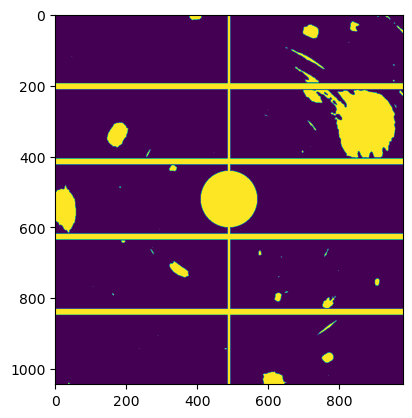

In [40]:
plt.imshow(integration_mask)

# Alternative: Testing Martin's integration method with his mask

In [11]:
from PIL import Image
from xypattern import Pattern

In [12]:
mask_file_path = glob(poni_dir + '/*.mask')
mask = np.array(Image.open(mask_file_path[0]))

im_file_path = glob(poni_dir + '/KM*.tiff')
im = np.array(Image.open(im_file_path[0]))

pattern = Pattern()
xy_file_path = glob(poni_dir + '/*.xy')
pattern.load(xy_file_path[0], skiprows = 0)




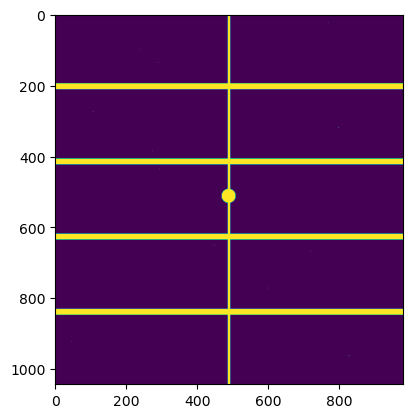

In [13]:
mask_file_path = glob(poni_dir + '/*.mask')
mask = np.array(Image.open(mask_file_path[0]))

bg_mask = im < 250
extremes_mask = im > 4000
# mask = mask | bg_mask | extremes_mask
# mask = np.logical_or(mask, bg_mask)

plt.imshow(mask)

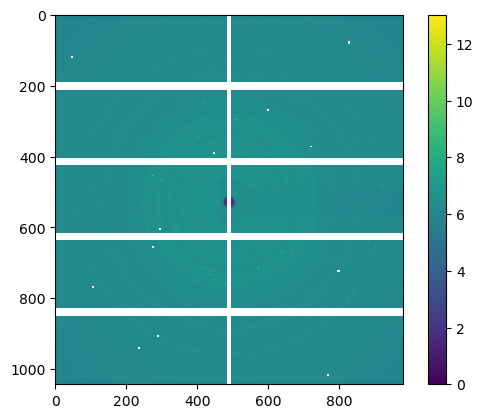

In [99]:
plt.imshow(np.log(im))
plt.colorbar()

# Integrating whatever the result is

In [14]:
tth, intensity = calibration_model.integrate_1d(im, mask=mask)
                                                # method='splitbbox')

Text(0.5, 1.0, "Martin's integration")

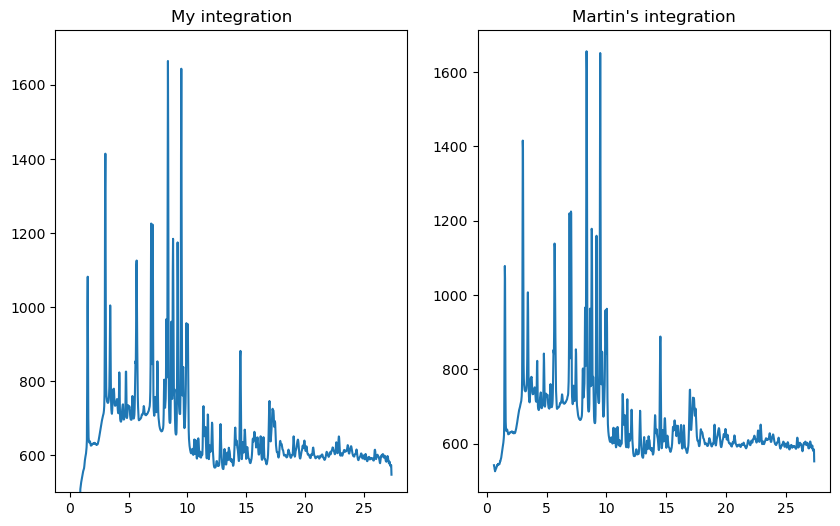

In [17]:
fig, axs = plt.subplots(1,2,figsize=(10,6))

axs[0].plot(tth, intensity)
axs[0].set_title("My integration")
axs[0].set_ylim(bottom=500)
axs[1].plot(pattern.data[0], pattern.data[1])
axs[1].set_title("Martin's integration")